In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers


In [20]:
df = pd.read_csv("IMDB_Dataset.csv")  # update path if needed
df = df[["review", "sentiment"]].dropna()

# Convert sentiment to 0/1
df["label"] = df["sentiment"].str.lower().map({"negative": 0, "positive": 1})

# Safety check
print(df.head())
print(df["sentiment"].value_counts())
print("Any unmapped labels?", df["label"].isna().sum())
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

                                              review sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production. <br /><br />The...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically there's a family where a little boy ...  negative      0
4  Petter Mattei's "Love in the Time of Money" is...  positive      1
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Any unmapped labels? 0


In [21]:
X = df["review"].astype(str).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 35000 Test: 15000


In [22]:

MAX_WORDS = 30000
MAX_LEN = 200

tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tok.fit_on_texts(X_train)

train_seq = tok.texts_to_sequences(X_train)
test_seq = tok.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [23]:
def build_lstm(vocab_size=MAX_WORDS, embed_dim=128, lstm_units=128, dropout=0.3):
    model = tf.keras.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=MAX_LEN),
        layers.Bidirectional(layers.LSTM(lstm_units)),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

lstm_model = build_lstm()
lstm_model.summary()

callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

c:\Users\Jude\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 110s 488ms/step - accuracy: 0.7412 - loss: 0.5023 - val_accuracy: 0.8526 - val_loss: 0.3453
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 101s 461ms/step - accuracy: 0.8937 - loss: 0.2772 - val_accuracy: 0.8744 - val_loss: 0.3288
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 467ms/step - accuracy: 0.9379 - loss: 0.1764 - val_accuracy: 0.8590 - val_loss: 0.3563
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 516ms/step - accuracy: 0.9642 - loss: 0.1086 - val_accuracy: 0.8404 - val_loss: 0.4276


469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step
LSTM Accuracy: 0.8724666666666666
LSTM F1: 0.8748446189074256
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      7500
           1       0.86      0.89      0.87      7500

    accuracy                           0.87     15000
   macro avg       0.87      0.87      0.87     15000
weighted avg       0.87      0.87      0.87     15000



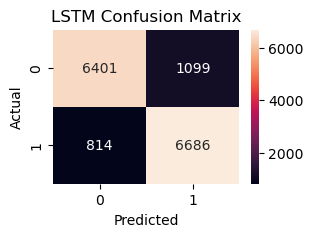

In [24]:
lstm_prob = lstm_model.predict(X_test_pad).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))
print("LSTM F1:", f1_score(y_test, lstm_pred))
print(classification_report(y_test, lstm_pred))

cm = confusion_matrix(y_test, lstm_pred)
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()